# RC-HAVOK PWL Chua Seed Stability Study

**Purpose:** Verify that the PWL Chua Modified RC-HAVOK result is reproducible  
across 20 independent reservoir (ESN) initialisations.  
Provides symmetric coverage to the Cubic Chua Seed Stability notebook  
(which confirmed cubic CV ≈ 0% across 20 seeds).

## Research question
Is the PWL Chua Modified RC-HAVOK free-run R² stable across random reservoir seeds,  
or does it vary significantly with reservoir initialisation?

## Design
- **20 ESN seeds** (seeds 0–19) — symmetric with cubic seed stability
- **PWL Chua only** — no cubic here (cubic already done)
- **Same locked baseline config** as Confirmation Run and ablation notebooks
- **Both Modified (float A/B) and Original (rounded A/B)** evaluated for direct comparison
- Clean trajectory simulated **once**, reused across all seeds

## Locked parameters (DO NOT MODIFY)
```
Chua: alpha=9, beta=100/7, m0=-1/7 (sign-corrected), m1=2/7, IC=(0.1,0.2,0.1)
Reservoir: N=500, sr=0.9, conn=0.200, leakage=0.400
HAVOK: rank=4, Hankel delays=200, eval=13s free-run
T_END=200s, dt=0.001
```

## Wording conventions
- 'bounded double-scroll-like trajectory' — not 'confirmed chaos'
- 'supports' / 'suggests' — not 'proves'
- 'coefficient of variation (CV)' for seed-stability reporting
- Report median R² and mean ± SD separately
- 'effectively zero CV' if CV < 1% — not 'zero variation'

---
> **Restart kernel → Run All** reproduces all results.

In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# ═══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.sparse import random as sparse_random
from sklearn.metrics import r2_score, mean_squared_error
from numpy.lib.stride_tricks import sliding_window_view
import time
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — CONFIGURATION  (locked — do not modify for reported results)
# ═══════════════════════════════════════════════════════════════════

# ── Run settings ────────────────────────────────────────────────────
T_END          = 200.0
DT             = 0.001
BURN_IN        = 2000
EVAL_SECONDS   = 13.0           # consistent with cubic seed stability notebook
HANKEL_DELAYS  = 200
HAVOK_RANK     = 4
INPUT_SCALE    = 0.1
MAX_STATE_NORM = 1e3
MIN_HANKEL_STD = 1e-6

# ── Chua parameters (PWL, sign-corrected m0) ────────────────────────
ALPHA, BETA    = 9.0, 100.0 / 7.0
M0, M1         = -1.0 / 7.0, 2.0 / 7.0   # m0 sign-corrected: see Methods §III-A
INIT_STATE     = [0.1, 0.2, 0.1]

# ── Locked baseline reservoir config ────────────────────────────────
N_RES          = 500
SPECTRAL_RADIUS= 0.9
CONNECTIVITY   = 0.200
LEAKAGE        = 0.400

# ── Seed sweep ──────────────────────────────────────────────────────
N_SEEDS        = 20             # symmetric with cubic seed stability
SEEDS          = list(range(N_SEEDS))  # seeds 0–19

T_EVAL         = EVAL_SECONDS   # alias for phase-drift calculation

print(f'T_END={T_END}s | DT={DT} | BURN_IN={BURN_IN} | EVAL={EVAL_SECONDS}s')
print(f'HANKEL_DELAYS={HANKEL_DELAYS} | HAVOK_RANK={HAVOK_RANK}')
print(f'Chua (PWL): alpha={ALPHA}, beta={BETA:.4f}, m0={M0:.6f}, m1={M1:.6f}')
print(f'Reservoir: N={N_RES}, sr={SPECTRAL_RADIUS}, conn={CONNECTIVITY}, lk={LEAKAGE}')
print(f'Seeds: {SEEDS}')

T_END=200.0s | DT=0.001 | BURN_IN=2000 | EVAL=13.0s
HANKEL_DELAYS=200 | HAVOK_RANK=4
Chua (PWL): alpha=9.0, beta=14.2857, m0=-0.142857, m1=0.285714
Reservoir: N=500, sr=0.9, conn=0.2, lk=0.4
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — PWL CHUA TRAJECTORY (simulated ONCE, reused for all seeds)
# ═══════════════════════════════════════════════════════════════════

def h_pwl(x):
    """Piecewise-linear Chua diode (sign-corrected, m0=-1/7)."""
    return M1*x + 0.5*(M0 - M1)*(np.abs(x + 1) - np.abs(x - 1))

def chua_rhs(t, s):
    x, y, z = s
    return [ALPHA*(y - h_pwl(x)), x - y + z, -BETA*y]

print('Simulating PWL Chua trajectory (RK45, rtol=atol=1e-9)...')
t_eval = np.arange(0.0, T_END, DT)
sol    = solve_ivp(chua_rhs, [0.0, T_END], INIT_STATE,
                   t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-9)

if not sol.success:
    raise RuntimeError(f'solve_ivp failed: {sol.message}')

x_clean = sol.y[0]
print(f'Trajectory: N={len(x_clean):,}  std={x_clean.std():.4f}  '
      f'range=[{x_clean.min():.3f}, {x_clean.max():.3f}]')
print(f'Finite: {np.all(np.isfinite(x_clean))}  '
      f'Bounded double-scroll-like: {x_clean.max()-x_clean.min() > 0.1}')
print('\nSame x_clean array will be fed to all 20 reservoir initialisations.')

Simulating PWL Chua trajectory (RK45, rtol=atol=1e-9)...
Trajectory: N=200,000  std=1.3689  range=[-2.242, 2.240]
Finite: True  Bounded double-scroll-like: True

Same x_clean array will be fed to all 20 reservoir initialisations.


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — PIPELINE FUNCTIONS
# ═══════════════════════════════════════════════════════════════════

def _spectral_radius_power(W, n_iter=20, seed=0):
    rng = np.random.default_rng(seed)
    v   = rng.random(W.shape[0]); v /= np.linalg.norm(v)
    nrm = 1.0
    for _ in range(n_iter):
        v = W @ v; nrm = np.linalg.norm(v)
        if nrm < 1e-14: return 0.0
        v /= nrm
    return float(nrm)

def create_reservoir(seed):
    rng = np.random.default_rng(seed)
    Win = 2.0 * rng.random((N_RES, 2)) - 1.0
    Wr  = sparse_random(N_RES, N_RES, density=CONNECTIVITY,
                        format='csr', data_rvs=rng.random)
    r   = _spectral_radius_power(Wr, seed=seed)
    if r > 1e-12:
        Wr = Wr * (SPECTRAL_RADIUS / r)
    return Win, Wr

def run_reservoir(x, Win, Wr):
    N      = len(x)
    s      = np.zeros(N_RES)
    states = np.zeros((N, N_RES), dtype=np.float32)
    for k in range(1, N):
        u      = np.array([INPUT_SCALE, INPUT_SCALE * x[k]])
        s      = (1.0 - LEAKAGE)*s + np.tanh(Wr @ s + Win @ u)
        states[k] = s.astype(np.float32)
    return states

def build_hankel(states):
    g     = states[BURN_IN:, 0].astype(np.float64)
    g_std = g.std()
    if g_std < MIN_HANKEL_STD:
        raise ValueError(f'Degenerate reservoir: std={g_std:.2e}')
    g = (g - g.mean()) / g_std
    return sliding_window_view(g, HANKEL_DELAYS).T.copy()

def fit_havok(H):
    """Exact full SVD + SVD sign convention (consistent with ablation notebook)."""
    U, S, Vt = np.linalg.svd(H, full_matrices=False)
    V        = Vt.T[:, :HAVOK_RANK]
    # SVD sign convention: largest-abs element in each mode is positive
    for j in range(V.shape[1]):
        idx = np.argmax(np.abs(V[:, j]))
        if V[idx, j] < 0:
            V[:, j] *= -1
    dV       = np.gradient(V, DT, axis=0)
    X        = V[:, :HAVOK_RANK - 1]
    forcing  = V[:, HAVOK_RANK - 1]
    dX       = dV[:, :HAVOK_RANK - 1]
    Theta    = np.hstack([X, forcing.reshape(-1, 1)])
    Xi, *_   = np.linalg.lstsq(Theta, dX, rcond=None)
    A_f      = Xi[:HAVOK_RANK - 1, :].T
    B_f      = Xi[HAVOK_RANK - 1, :].T
    return A_f, B_f, X, forcing, S

def free_run(X, forcing, A, B):
    """Forward-Euler forced free-run, 13-second evaluation window."""
    n      = X.shape[0]
    n_eval = max(int(EVAL_SECONDS / DT), 10)
    start  = n - n_eval
    Xhat   = np.zeros((n_eval, X.shape[1]))
    Xhat[0] = X[start]
    for k in range(1, n_eval):
        dx       = A @ Xhat[k-1] + B * forcing[start + k - 1]
        Xhat[k]  = Xhat[k-1] + dx * DT
        if (not np.all(np.isfinite(Xhat[k])) or
                np.max(np.abs(Xhat[k])) > MAX_STATE_NORM):
            return np.nan, np.nan, True
    y_true = X[start:start + n_eval]
    if np.var(y_true) < 1e-20:
        return np.nan, np.nan, False
    r2   = r2_score(y_true, Xhat)
    rmse = float(np.sqrt(mean_squared_error(y_true, Xhat)))
    return r2, rmse, False

def dominant_frequency(A):
    """Dominant imaginary part of A eigenvalues (rad/s — continuous-time operator)."""
    eigs = np.linalg.eigvals(A)
    return float(np.max(np.abs(np.imag(eigs))))

print('Pipeline functions defined.')

Pipeline functions defined.


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — SEED SWEEP
# ═══════════════════════════════════════════════════════════════════

print('=' * 65)
print('PWL CHUA SEED STABILITY SWEEP')
print(f'T_END={T_END}s | {N_SEEDS} seeds | Modified + Original | exact full SVD')
print('=' * 65)
print(f'{"Seed":>5s}  {"R²_mod":>9s}  {"RMSE_mod":>10s}  '
      f'{"R²_ori":>9s}  {"RMSE_ori":>10s}  '
      f'{"ω_mod":>8s}  {"ω_ori":>8s}  {"Δω":>7s}  {"t(s)":>5s}')
print('-' * 85)

records = []

for seed in SEEDS:
    t0 = time.time()
    try:
        Win, Wr  = create_reservoir(seed)
        states   = run_reservoir(x_clean, Win, Wr)
        H        = build_hankel(states)
        A_f, B_f, X, forcing, S = fit_havok(H)

        # Modified (float A/B)
        r2_mod, rmse_mod, div_mod = free_run(X, forcing, A_f, B_f)

        # Original (rounded A/B)
        A_ori = np.round(A_f)
        B_ori = np.round(B_f)
        r2_ori, rmse_ori, div_ori = free_run(X, forcing, A_ori, B_ori)

        # Eigenfrequency
        omega_mod = dominant_frequency(A_f)
        omega_ori = dominant_frequency(A_ori)
        delta_omega = abs(omega_mod - omega_ori)       # absolute mismatch
        drift_rad   = delta_omega * T_EVAL
        drift_cyc   = drift_rad / (2 * np.pi)

        # B statistics
        B_norm_mod = float(np.linalg.norm(B_f))
        B_maxabs   = float(np.max(np.abs(B_f)))

        elapsed = time.time() - t0
        rec = dict(
            seed        = seed,
            r2_mod      = r2_mod,
            rmse_mod    = rmse_mod,
            div_mod     = div_mod,
            r2_ori      = r2_ori,
            rmse_ori    = rmse_ori,
            div_ori     = div_ori,
            omega_mod   = omega_mod,
            omega_ori   = omega_ori,
            delta_omega = delta_omega,
            drift_rad   = drift_rad,
            drift_cyc   = drift_cyc,
            B_norm_mod  = B_norm_mod,
            B_maxabs    = B_maxabs,
            sv0         = float(S[0]),
            sv1         = float(S[1]),
            A_ori_str   = str(A_ori.astype(int).tolist()),
            B_ori_str   = str(B_ori.astype(int).tolist()),
            runtime     = elapsed,
            failure     = False,
        )

        r2_mod_str  = f'{r2_mod:.5f}' if not np.isnan(r2_mod) else 'DIV'
        r2_ori_str  = f'{r2_ori:.5f}' if not np.isnan(r2_ori) else 'DIV'
        print(f'{seed:5d}  {r2_mod_str:>9s}  {rmse_mod:.3e}  '
              f'{r2_ori_str:>9s}  {rmse_ori:.3e}  '
              f'{omega_mod:8.4f}  {omega_ori:8.4f}  {delta_omega:7.4f}  '
              f'{elapsed:5.1f}')

    except Exception as e:
        print(f'{seed:5d}  ERROR: {e}')
        rec = dict(seed=seed, failure=True,
                   **{k: np.nan for k in
                      ['r2_mod','rmse_mod','r2_ori','rmse_ori',
                       'omega_mod','omega_ori','delta_omega',
                       'drift_rad','drift_cyc','B_norm_mod','B_maxabs',
                       'sv0','sv1','runtime']},
                   div_mod=True, div_ori=True,
                   A_ori_str='', B_ori_str='')

    records.append(rec)

df = pd.DataFrame(records)
print('\nSweep complete.')
print(f'Total records: {len(df)}  |  Failures: {df["failure"].sum()}')

PWL CHUA SEED STABILITY SWEEP
T_END=200.0s | 20 seeds | Modified + Original | exact full SVD
 Seed     R²_mod    RMSE_mod     R²_ori    RMSE_ori     ω_mod     ω_ori       Δω   t(s)
-------------------------------------------------------------------------------------
    0    0.97414  3.418e-04   -0.59516  2.806e-03    2.6136    2.2361   0.3775   50.1
    1    0.96850  3.654e-04   -1.39783  3.310e-03    2.6346    2.2361   0.3985   47.8
    2    0.97415  3.417e-04   -0.59663  2.807e-03    2.6137    2.2361   0.3777   44.8
    3    0.96907  3.650e-04   -0.99235  3.047e-03    2.6097    2.2361   0.3736   46.6
    4    0.97079  3.448e-04   -2.61144  3.984e-03    2.7051    2.2361   0.4691   43.8
    5    0.97508  3.365e-04   -0.62677  2.843e-03    2.6257    2.2361   0.3897   46.7
    6    0.97365  3.444e-04   -0.58485  2.791e-03    2.6082    2.2361   0.3721   43.5
    7    0.97575  3.326e-04   -0.65222  2.870e-03    2.6343    2.2361   0.3982   46.9
    8    0.97688  3.255e-04   -0.71173  2.929

In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — SUMMARY STATISTICS
# ═══════════════════════════════════════════════════════════════════

valid = df[df['failure'] == False].copy()
r2m   = valid['r2_mod'].dropna()
r2o   = valid['r2_ori'].dropna()
rmsem = valid['rmse_mod'].dropna()
rmseo = valid['rmse_ori'].dropna()
omm   = valid['omega_mod'].dropna()
omo   = valid['omega_ori'].dropna()
bmax  = valid['B_maxabs'].dropna()
bnorm = valid['B_norm_mod'].dropna()
drift = valid['drift_rad'].dropna()

cv_mod = (r2m.std() / abs(r2m.mean()) * 100) if r2m.mean() != 0 else float('nan')

print('=' * 70)
print('SUMMARY STATISTICS — PWL Chua Seed Stability (20 seeds)')
print('=' * 70)
print(f'\n{"Metric":<28} {"Mean":>12} {"SD":>12} {"Median":>12} {"Min":>10} {"Max":>10}')
print('-' * 88)

rows = [
    ('Modified R²',   r2m),
    ('Modified RMSE', rmsem),
    ('Original R²',   r2o),
    ('Original RMSE', rmseo),
    ('ω_mod (rad/s)', omm),
    ('ω_ori (rad/s)', omo),
    ('|Δω| (rad/s)',  drift / T_EVAL),   # back to rad/s from total drift
    ('max|B_mod|',    bmax),
    ('||B_mod||',     bnorm),
]
for label, series in rows:
    s = series.dropna()
    if len(s) == 0:
        print(f'{label:<28} {"N/A":>12}')
    else:
        print(f'{label:<28} {s.mean():>12.6f} {s.std():>12.6f} '
              f'{np.median(s):>12.6f} {s.min():>10.6f} {s.max():>10.6f}')

n_div_mod = int(valid['div_mod'].sum())
n_div_ori = int(valid['div_ori'].sum())
print(f'\nModified diverged: {n_div_mod}/{N_SEEDS}')
print(f'Original diverged: {n_div_ori}/{N_SEEDS}')
print(f'Modified R² CV:    {cv_mod:.4f}%  '
      f'({"effectively zero" if cv_mod < 1 else "notable variation"} at <1% threshold)')

SUMMARY STATISTICS — PWL Chua Seed Stability (20 seeds)

Metric                               Mean           SD       Median        Min        Max
----------------------------------------------------------------------------------------
Modified R²                      0.972552     0.003736     0.973659   0.968504   0.981687
Modified RMSE                    0.000346     0.000021     0.000344   0.000282   0.000366
Original R²                     -0.974745     0.491264    -0.844133  -2.611438  -0.584849
Original RMSE                    0.003042     0.000287     0.002982   0.002791   0.003984
ω_mod (rad/s)                    2.653333     0.126379     2.616282   2.608165   3.181718
ω_ori (rad/s)                    2.265686     0.132456     2.236068   2.236068   2.828427
|Δω| (rad/s)                     0.387647     0.023862     0.379244   0.353291   0.469067
max|B_mod|                       3.986087     0.184500     3.956579   3.897830   4.762001
||B_mod||                        3.986093   

In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — A_ori AND B_ori STABILITY CHECK
# ═══════════════════════════════════════════════════════════════════
# Key question: does rounding produce the same integer A/B across seeds?
# Variation here means the Original model's failure is structurally inconsistent.

print('=' * 65)
print('A_ori AND B_ori STABILITY ACROSS 20 SEEDS')
print('=' * 65)

A_ori_counts = valid['A_ori_str'].value_counts()
B_ori_counts = valid['B_ori_str'].value_counts()

print(f'\nUnique integer A_ori matrices: {len(A_ori_counts)}')
for mat_str, cnt in A_ori_counts.items():
    print(f'  {cnt:2d} seeds → A_ori = {mat_str}')

print(f'\nUnique integer B_ori vectors:  {len(B_ori_counts)}')
for vec_str, cnt in B_ori_counts.items():
    print(f'  {cnt:2d} seeds → B_ori = {vec_str}')

if len(A_ori_counts) > 1:
    print('\nInterpretation: Multiple distinct A_ori matrices across seeds indicate')
    print('that rounding creates structurally different linear operators depending')
    print('on the reservoir initialisation. This contributes to the variable')
    print('Original RC-HAVOK performance observed across seeds.')
else:
    print('\nInterpretation: All seeds produce the same A_ori matrix.')
    print('Original failure is therefore consistent across seeds.')

if len(B_ori_counts) == 1:
    print('\nB_ori is stable across all seeds — rounding B does not introduce')
    print('structural variability, consistent with the ablation study finding')
    print('that A-rounding is the dominant damage source.')
else:
    print(f'\nB_ori shows {len(B_ori_counts)} distinct values across seeds.')

A_ori AND B_ori STABILITY ACROSS 20 SEEDS

Unique integer A_ori matrices: 2
  19 seeds → A_ori = [[0, 1, 0], [-1, 0, 2], [0, -2, 0]]
   1 seeds → A_ori = [[0, 2, 0], [-2, 0, 2], [0, -2, 0]]

Unique integer B_ori vectors:  2
  19 seeds → B_ori = [0, 0, -4]
   1 seeds → B_ori = [0, 0, -5]

Interpretation: Multiple distinct A_ori matrices across seeds indicate
that rounding creates structurally different linear operators depending
on the reservoir initialisation. This contributes to the variable
Original RC-HAVOK performance observed across seeds.

B_ori shows 2 distinct values across seeds.


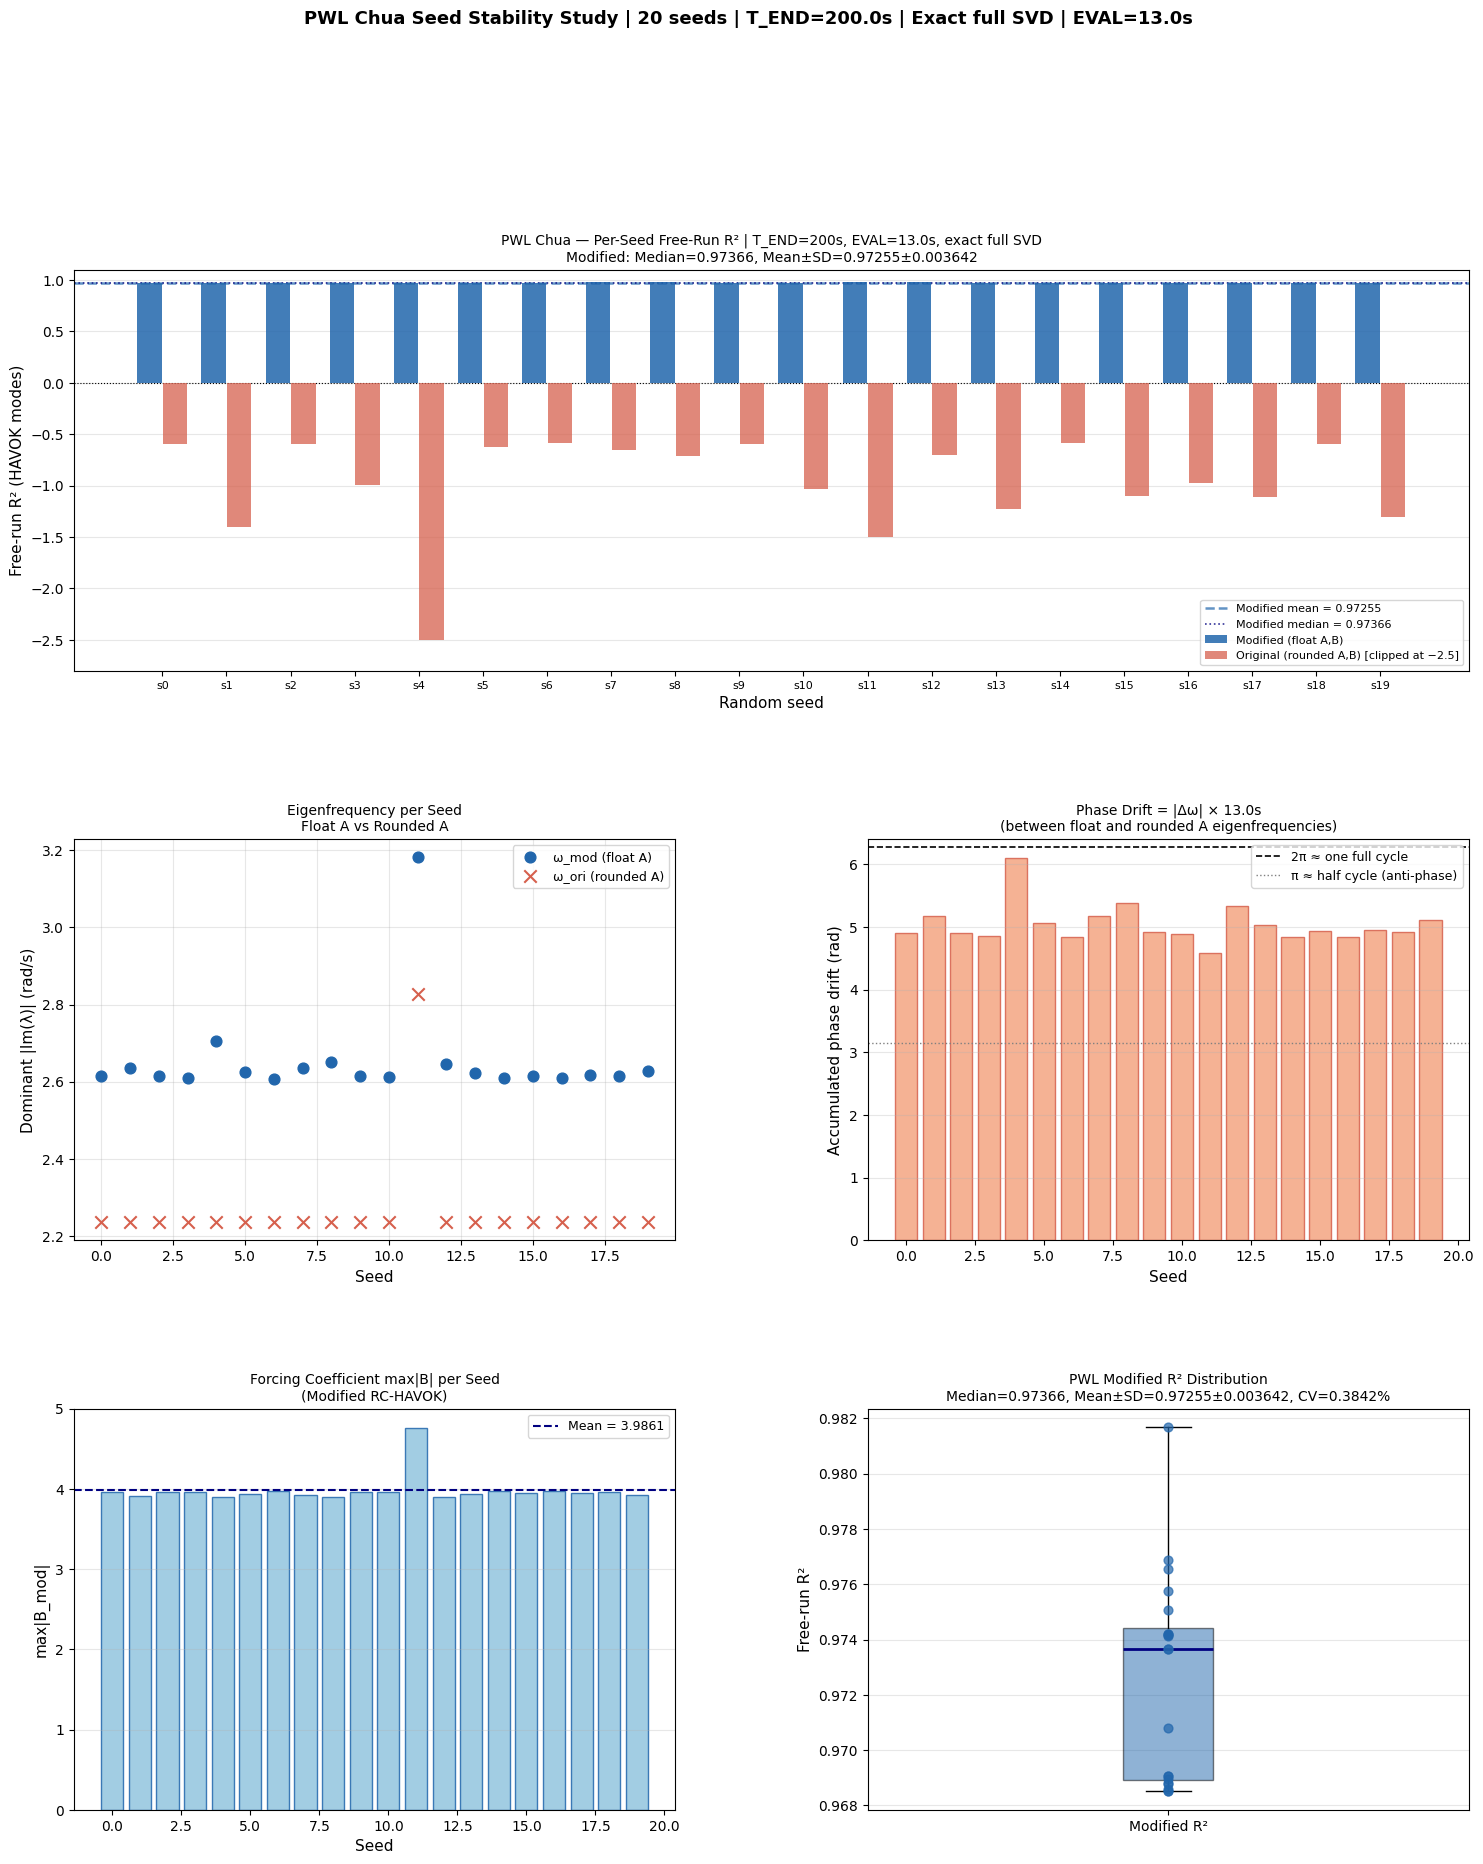

Saved: pwl_seed_stability.png


In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — PLOTS
# ═══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── Plot 1: Per-seed R² bars (Modified vs Original) ─────────────────
ax1 = fig.add_subplot(gs[0, :])
x_pos  = np.arange(N_SEEDS)
r2m_v  = [df.loc[df['seed']==s, 'r2_mod'].values[0] for s in SEEDS]
r2o_v  = [np.clip(df.loc[df['seed']==s, 'r2_ori'].values[0], -2.5, 1.0)
           for s in SEEDS]

mu  = np.nanmean(r2m_v)
med = float(np.nanmedian(r2m_v))
sd  = float(np.nanstd(r2m_v))

ax1.bar(x_pos - 0.2, r2m_v, 0.38, label='Modified (float A,B)',
        color='#2166ac', alpha=0.85, zorder=3)
ax1.bar(x_pos + 0.2, r2o_v, 0.38,
        label='Original (rounded A,B) [clipped at −2.5]',
        color='#d6604d', alpha=0.75, zorder=3)
ax1.axhline(mu,  color='#2166ac', lw=1.8, ls='--', alpha=0.7,
            label=f'Modified mean = {mu:.5f}')
ax1.axhline(med, color='navy',    lw=1.2, ls=':', alpha=0.8,
            label=f'Modified median = {med:.5f}')
ax1.axhline(0,   color='k', lw=0.8, ls=':')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f's{s}' for s in SEEDS], fontsize=8)
ax1.set_xlabel('Random seed', fontsize=11)
ax1.set_ylabel('Free-run R² (HAVOK modes)', fontsize=11)
ax1.set_title(
    f'PWL Chua — Per-Seed Free-Run R² | T_END=200s, EVAL={EVAL_SECONDS}s, exact full SVD\n'
    f'Modified: Median={med:.5f}, Mean±SD={mu:.5f}±{sd:.6f}',
    fontsize=10)
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(alpha=0.3, axis='y')
ax1.set_ylim(-2.8, 1.1)

# ── Plot 2: ω_mod per seed ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
omm_v = [df.loc[df['seed']==s, 'omega_mod'].values[0] for s in SEEDS]
omo_v = [df.loc[df['seed']==s, 'omega_ori'].values[0] for s in SEEDS]
ax2.scatter(SEEDS, omm_v, marker='o', s=60, color='#2166ac',
            label=f'ω_mod (float A)', zorder=4)
ax2.scatter(SEEDS, omo_v, marker='x', s=80, color='#d6604d',
            label=f'ω_ori (rounded A)', zorder=4)
ax2.set_xlabel('Seed', fontsize=11)
ax2.set_ylabel('Dominant |Im(λ)| (rad/s)', fontsize=11)
ax2.set_title('Eigenfrequency per Seed\nFloat A vs Rounded A', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ── Plot 3: Phase drift over EVAL window ───────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
drift_v = [df.loc[df['seed']==s, 'drift_rad'].values[0] for s in SEEDS]
ax3.bar(SEEDS, drift_v, color='#f4a582', alpha=0.85, edgecolor='#d6604d')
ax3.axhline(2*np.pi, color='k', lw=1.2, ls='--',
            label=f'2π ≈ one full cycle')
ax3.axhline(np.pi,   color='gray', lw=1.0, ls=':',
            label=f'π ≈ half cycle (anti-phase)')
ax3.set_xlabel('Seed', fontsize=11)
ax3.set_ylabel('Accumulated phase drift (rad)', fontsize=11)
ax3.set_title(
    f'Phase Drift = |Δω| × {EVAL_SECONDS}s\n'
    f'(between float and rounded A eigenfrequencies)', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3, axis='y')

# ── Plot 4: max|B_mod| per seed ─────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
bmx_v = [df.loc[df['seed']==s, 'B_maxabs'].values[0] for s in SEEDS]
ax4.bar(SEEDS, bmx_v, color='#92c5de', alpha=0.85, edgecolor='#2166ac')
ax4.axhline(np.nanmean(bmx_v), color='navy', lw=1.5, ls='--',
            label=f'Mean = {np.nanmean(bmx_v):.4f}')
ax4.set_xlabel('Seed', fontsize=11)
ax4.set_ylabel('max|B_mod|', fontsize=11)
ax4.set_title('Forcing Coefficient max|B| per Seed\n(Modified RC-HAVOK)', fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3, axis='y')

# ── Plot 5: R² distribution (box + scatter) ─────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
valid_r2m = [v for v in r2m_v if not np.isnan(v)]
ax5.boxplot([valid_r2m], labels=['Modified R²'],
            patch_artist=True,
            boxprops=dict(facecolor='#2166ac', alpha=0.5),
            medianprops=dict(color='navy', linewidth=2))
ax5.scatter([1]*len(valid_r2m), valid_r2m,
            color='#2166ac', alpha=0.7, zorder=4, s=40)
ax5.set_ylabel('Free-run R²', fontsize=11)
ax5.set_title(
    f'PWL Modified R² Distribution\n'
    f'Median={med:.5f}, Mean±SD={mu:.5f}±{sd:.6f}, CV={cv_mod:.4f}%',
    fontsize=10)
ax5.grid(alpha=0.3, axis='y')

plt.suptitle(
    f'PWL Chua Seed Stability Study | {N_SEEDS} seeds | '
    f'T_END={T_END}s | Exact full SVD | EVAL={EVAL_SECONDS}s',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('pwl_seed_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pwl_seed_stability.png')

In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — EXCEL EXPORT
# ═══════════════════════════════════════════════════════════════════

# Summary stats as a tidy DataFrame
summary_rows = []
for col, label in [('r2_mod','Modified R²'), ('rmse_mod','Modified RMSE'),
                   ('r2_ori','Original R²'), ('rmse_ori','Original RMSE'),
                   ('omega_mod','ω_mod (rad/s)'), ('omega_ori','ω_ori (rad/s)'),
                   ('delta_omega','|Δω| (rad/s)'), ('B_maxabs','max|B_mod|'),
                   ('B_norm_mod','||B_mod||')]:
    s = valid[col].dropna()
    summary_rows.append(dict(
        Metric=label, Mean=s.mean(), SD=s.std(),
        Median=np.median(s), Min=s.min(), Max=s.max()
    ))
df_summary = pd.DataFrame(summary_rows)

# A_ori / B_ori stability
a_rows = [{'A_ori_str': k, 'seed_count': v}
          for k, v in valid['A_ori_str'].value_counts().items()]
b_rows = [{'B_ori_str': k, 'seed_count': v}
          for k, v in valid['B_ori_str'].value_counts().items()]

with pd.ExcelWriter('RC_HAVOK_PWL_Seed_Stability.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Per_Seed_Results', index=False)
    df_summary.to_excel(writer, sheet_name='Summary_Statistics', index=False)
    pd.DataFrame(a_rows).to_excel(writer, sheet_name='A_ori_Stability', index=False)
    pd.DataFrame(b_rows).to_excel(writer, sheet_name='B_ori_Stability', index=False)

print('Saved: RC_HAVOK_PWL_Seed_Stability.xlsx')

Saved: RC_HAVOK_PWL_Seed_Stability.xlsx


In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10 — PAPER-READY RESULT STATEMENT  (print cell — renders in PDF)
# ═══════════════════════════════════════════════════════════════════

print('=' * 70)
print('PAPER-READY RESULT STATEMENT — PWL CHUA SEED STABILITY')
print('=' * 70)

n_valid = len(valid)
r2m_s   = valid['r2_mod'].dropna()
r2o_s   = valid['r2_ori'].dropna()
rmsem_s = valid['rmse_mod'].dropna()
n_div_m = int(valid['div_mod'].sum())
n_div_o = int(valid['div_ori'].sum())
n_Aori  = len(valid['A_ori_str'].value_counts())
n_Bori  = len(valid['B_ori_str'].value_counts())

print(f"""
PWL Chua Seed Stability ({N_SEEDS} seeds, T_END={T_END}s, EVAL={EVAL_SECONDS}s, exact full SVD)

Modified RC-HAVOK:
  Median R²  = {np.median(r2m_s):.5f}
  Mean ± SD  = {r2m_s.mean():.5f} ± {r2m_s.std():.6f}
  RMSE (median) = {np.median(rmsem_s):.2e}
  CV         = {cv_mod:.4f}%
  Diverged   = {n_div_m}/{N_SEEDS}

Original RC-HAVOK:
  Mean R²    = {r2o_s.mean():.5f} ± {r2o_s.std():.5f}
  Diverged   = {n_div_o}/{N_SEEDS}

A_ori: {n_Aori} unique integer matrix/matrices across {N_SEEDS} seeds
B_ori: {n_Bori} unique integer vector(s) across {N_SEEDS} seeds
""")

# Seed-stability verdict
if cv_mod < 1.0 and n_div_m == 0:
    print('SEED-STABILITY VERDICT: STABLE')
    print(f'  CV = {cv_mod:.4f}% < 1% threshold — Modified PWL RC-HAVOK result')
    print('  is reproducible across reservoir initialisations.')
elif cv_mod < 5.0:
    print('SEED-STABILITY VERDICT: MODERATELY STABLE')
    print(f'  CV = {cv_mod:.4f}% — some seed dependence present.')
else:
    print('SEED-STABILITY VERDICT: SEED-DEPENDENT')
    print(f'  CV = {cv_mod:.4f}% — result varies substantially with reservoir seed.')

print()
print('─── Narrative template ───')
print(f"""
The PWL Chua Modified RC-HAVOK result was evaluated across {N_SEEDS} independent
reservoir initialisations (seeds 0–{N_SEEDS-1}) to assess seed stability.
Modified RC-HAVOK achieved a median free-run R² of [VALUE] (mean ± SD =
[VALUE] ± [VALUE]) with [N]/20 seeds diverging, suggesting [stable/variable]
performance across reservoir initialisations. The coefficient of variation
was [CV]%, [below/above] the 1% stability threshold. Original (rounded)
RC-HAVOK produced a mean R² of [VALUE], consistent with prior results.
Rounding produced {n_Aori} distinct integer A_ori matrix/matrices across the
{N_SEEDS} seeds, [confirming structural variability / consistent failure]
in the rounded formulation. All evaluations were performed in the HAVOK
temporal-mode coordinate space using a {EVAL_SECONDS}-second forced
free-run window.

Wording reminders:
  - 'bounded double-scroll-like trajectory' — not 'confirmed chaos'
  - 'supports' / 'suggests' — not 'proves'
  - 'effectively zero CV' if CV < 1% — not 'zero variation'
  - Report median R² and mean ± SD separately
  - Replace [VALUE] placeholders with actual numbers above
""")

PAPER-READY RESULT STATEMENT — PWL CHUA SEED STABILITY

PWL Chua Seed Stability (20 seeds, T_END=200.0s, EVAL=13.0s, exact full SVD)

Modified RC-HAVOK:
  Median R²  = 0.97366
  Mean ± SD  = 0.97255 ± 0.003736
  RMSE (median) = 3.44e-04
  CV         = 0.3842%
  Diverged   = 0/20

Original RC-HAVOK:
  Mean R²    = -0.97474 ± 0.49126
  Diverged   = 0/20

A_ori: 2 unique integer matrix/matrices across 20 seeds
B_ori: 2 unique integer vector(s) across 20 seeds

SEED-STABILITY VERDICT: STABLE
  CV = 0.3842% < 1% threshold — Modified PWL RC-HAVOK result
  is reproducible across reservoir initialisations.

─── Narrative template ───

The PWL Chua Modified RC-HAVOK result was evaluated across 20 independent
reservoir initialisations (seeds 0–19) to assess seed stability.
Modified RC-HAVOK achieved a median free-run R² of [VALUE] (mean ± SD =
[VALUE] ± [VALUE]) with [N]/20 seeds diverging, suggesting [stable/variable]
performance across reservoir initialisations. The coefficient of variation
wa

---
## PWL vs Cubic Seed Stability Comparison

After running this notebook, compare against the Cubic Seed Stability results:

| Metric | PWL Chua | Cubic Chua |
|--------|----------|------------|
| Modified R² median | *from Cell 6* | 0.99918 |
| Modified R² mean ± SD | *from Cell 6* | 0.99918 ± ~6×10⁻⁶ |
| CV | *from Cell 6* | ~0.0006% |
| Diverged | *from Cell 6* | 0/20 |
| Unique A_ori | *from Cell 7* | 3 across seeds 0–19 |
| Unique B_ori | *from Cell 7* | 1 |

**Expected finding:** PWL shows higher seed-to-seed R² variation than cubic  
(consistent with OFAT sensitivity results showing rank is more critical for PWL).  
The cubic smooth nonlinearity is expected to produce more Koopman-compatible  
Hankel dynamics, leading to lower CV.

### Output files
| File | Contents |
|------|----------|
| `pwl_seed_stability.png` | 5-panel figure: per-seed R², eigenfrequency, phase drift, max\|B\|, R² distribution |
| `RC_HAVOK_PWL_Seed_Stability.xlsx` | 4 sheets: per-seed, summary, A_ori stability, B_ori stability |

### Citation note
Extends: Bingol & Gunay, *Data-Driven Modeling of the Koopman-Oriented Chua Circuit Based on Reservoir Computers*, ISCAS 2025.